In [103]:
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import zipfile
import bs4
import os
import re

In [104]:
SRC_LIST_PATH = os.path.join("data", "docs", "databank-list.txt")

with open(SRC_LIST_PATH, 'r') as f:
    databank_list = [src.strip('\n') for src in f.readlines()]

databank_list

['Agricultural land (% of land area)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Rural population (% of total population)',
 'Net migration',
 'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)',
 'Pregnant women receiving prenatal care (%)',
 'Prevalence of HIV, total (% of population ages 15-49)',
 'Primary completion rate, total (% of relevant age group)',
 'School enrollment, primary and secondary (gross), gender parity index (GPI)',
 'Access to electricity (% of population)',
 'Population growth (annual %)',
 'Population in urban agglomerations of more than 1 million (% of total population)',
 'Population living in areas where elevation is below 5 meters (% of total population)',
 'Terrestrial and marine protected areas (% of total territorial area)',
 'Urban population (% of total population)',
 'Central government debt, total (% of GDP)',
 'Expense (% of GDP)',
 'GDP growth (annual %)',
 'GDP per capita growth (annual %)',
 

In [105]:
DATABANK_URL = "https://data.worldbank.org/indicator"
DATABANK_INDICATORS_PATH = os.path.join("data", "html", "databank-indicators.html")

if not os.path.exists(DATABANK_INDICATORS_PATH):
    urlretrieve(DATABANK_URL, DATABANK_INDICATORS_PATH)

In [106]:
with open(DATABANK_INDICATORS_PATH, 'r', encoding='utf-8') as f:
    html_text = f.read()
    soup = bs4.BeautifulSoup(html_text, 'html.parser')
    indicator_links = soup.find_all('a', href=re.compile("/indicator/"))

In [107]:
API_DOWNLOAD_URL = "https://api.worldbank.org/v2/en/indicator/"
download_links = []
for indicator_name in databank_list:
    name = indicator_name.replace(" ", "").lower()
    for link in indicator_links:
        if link.text.replace(" ", "").lower() == name:
            code = link.get("href").split("/")[2]
            download_url = f"{API_DOWNLOAD_URL}{code}?downloadformat=csv"
            download_links.append((indicator_name, code, download_url))
download_links

[('Agricultural land (% of land area)',
  'AG.LND.AGRI.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.AGRI.ZS?downloadformat=csv'),
 ('Agricultural land (% of land area)',
  'AG.LND.AGRI.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.AGRI.ZS?downloadformat=csv'),
 ('Agricultural land (% of land area)',
  'AG.LND.AGRI.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.AGRI.ZS?downloadformat=csv'),
 ('Food production index (2014-2016 = 100)',
  'AG.PRD.FOOD.XD',
  'https://api.worldbank.org/v2/en/indicator/AG.PRD.FOOD.XD?downloadformat=csv'),
 ('Forest area (% of land area)',
  'AG.LND.FRST.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.FRST.ZS?downloadformat=csv'),
 ('Forest area (% of land area)',
  'AG.LND.FRST.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.FRST.ZS?downloadformat=csv'),
 ('Forest area (% of land area)',
  'AG.LND.FRST.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.FRST.ZS?downloadformat=csv'),
 ('Rural population

In [108]:
for name, code, url in download_links:
    path = os.path.join("data", "zip", f"{name}.zip")
    if not os.path.exists(path):
        urlretrieve(url, path)

In [109]:
ZIP_PATH = os.path.join("data", "zip")
CSV_PATH = os.path.join("data", "csv")

In [110]:
for file in os.listdir(ZIP_PATH):
    file_dir = os.path.join(CSV_PATH, file.replace(".zip", ""))
    if not os.path.exists(file_dir):
        os.mkdir(file_dir)
        zipfile.ZipFile(os.path.join(ZIP_PATH, file), 'r').extractall(file_dir)

In [111]:
# Get happiness data
HAPPINESS_URL = "https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx"

# Automated retrieval is forbidden (403), so manual retrieval was needed.
# File is stored, manually, in defined location at `data/xlsx/happiness_report.xlsx`
# urlretrieve(HAPPINESS_URL, os.path.join("data", "xlsx", "happiness_report.xlsx"))

# Data preliminary exploration

## Happiness data

In [112]:
happiness = pd.read_excel(os.path.join("data", "xlsx", "happiness_report.xlsx"))
happiness.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [113]:
happiness.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

We are interested in the year, country name, and life evaluation average.

In [114]:
happiness["Life evaluation (3-year average)"].describe()

count    2116.000000
mean        5.465655
std         1.123870
min         1.364000
25%         4.604750
50%         5.480000
75%         6.321250
max         7.856000
Name: Life evaluation (3-year average), dtype: float64

In [115]:
happiness_df = happiness.loc[:, ["Year", "Country name", "Life evaluation (3-year average)"]]
MAX_YEAR, MIN_YEAR = happiness_df["Year"].max(), happiness_df["Year"].min()
COUNTRIES_LIST = happiness_df["Country name"].unique()

MAX_YEAR, MIN_YEAR, COUNTRIES_LIST

(np.int64(2025),
 np.int64(2011),
 <StringArray>
 [          'Finland',           'Iceland',           'Denmark',
         'Costa Rica',            'Sweden',            'Norway',
        'Netherlands',            'Israel',        'Luxembourg',
        'Switzerland',
  ...
             'Bhutan',             'Syria',             'Sudan',
             'Angola',       'Puerto Rico',          'Suriname',
  'Somaliland Region',          'Djibouti',            'Guyana',
               'Cuba']
 Length: 168, dtype: str)

## Bank data

In [116]:
indicator_names = os.listdir(CSV_PATH)
indicator_files = dict()
for indicator in indicator_names:
    dir_path = os.path.join(CSV_PATH, indicator)
    if os.path.isdir(dir_path):
        files = os.listdir(dir_path)
        for f in files:
            if not f.startswith("Metadata"):
                indicator_files[indicator] = os.path.join(CSV_PATH, indicator, f)
indicator_files

{'Access to electricity (% of population)': 'data\\csv\\Access to electricity (% of population)\\API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_3606.csv',
 'Agricultural land (% of land area)': 'data\\csv\\Agricultural land (% of land area)\\API_AG.LND.AGRI.ZS_DS2_en_csv_v2_7781.csv',
 'Alternative and nuclear energy (% of total energy use)': 'data\\csv\\Alternative and nuclear energy (% of total energy use)\\API_EG.USE.COMM.CL.ZS_DS2_en_csv_v2_7080.csv',
 'Central government debt, total (% of GDP)': 'data\\csv\\Central government debt, total (% of GDP)\\API_GC.DOD.TOTL.GD.ZS_DS2_en_csv_v2_5449.csv',
 'Expense (% of GDP)': 'data\\csv\\Expense (% of GDP)\\API_GC.XPN.TOTL.GD.ZS_DS2_en_csv_v2_2867.csv',
 'Food production index (2014-2016 = 100)': 'data\\csv\\Food production index (2014-2016 = 100)\\API_AG.PRD.FOOD.XD_DS2_en_csv_v2_15376.csv',
 'Forest area (% of land area)': 'data\\csv\\Forest area (% of land area)\\API_AG.LND.FRST.ZS_DS2_en_csv_v2_4195.csv',
 'Fossil fuel energy consumption (% of tota

**Note:** Every csv file starts at row 2!

### Access to electricity

In [117]:
electricity = pd.read_csv(indicator_files["Access to electricity (% of population)"], header=2)
electricity.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000,NaN,NaN,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.902228,51.338199,51.289374,51.851866,54.366012,55.683570,57.064737,NaN,NaN,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000,NaN,NaN,NaN


In [118]:
electricity.describe(), electricity.info()

<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    str    
 1   Country Code    265 non-null    str    
 2   Indicator Name  265 non-null    str    
 3   Indicator Code  265 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

(       1960  1961  1962  1963  1964  1965  1966  1967  1968  1969  ...  \
 count   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
 mean    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 std     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 min     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 25%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 50%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 75%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 max     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 
              2017        2018        2019        2020        2021        2022  \
 count  262.000000  262.000000  262.000000  262.000000  262.000000  262.000000   
 mean    84.677662   85.315478   85.874072   86.408904   86.969251   87.263447   
 std     24.907559   24.049449   23.793819   23.387846   22.846938   22.45256

# Data preparation

In [119]:
# Melting the bank data df
id_vars = ["Country Name", "Indicator Name"]
year_cols = [col for col in electricity.columns if col.isdigit()]
electricity_long = pd.melt(electricity,
        id_vars=id_vars,
        value_vars=year_cols,
        var_name="Year",
        value_name="Value")

# For compatibility, transform year strings into integers:
electricity_long["Year"] = electricity_long["Year"].astype("int")

# Now, Indicator Name must be removed and the Value column should be renamed:
indicator_name = electricity_long["Indicator Name"][0]
electricity_long.rename(columns={"Value": indicator_name}, inplace=True)
electricity_long.drop(columns=["Indicator Name"], inplace=True)

# Also, the country column should be renamed for compatibility:
electricity_long.rename(columns={"Country Name":"Country name"}, inplace=True)

# Check the results
electricity_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 17490 entries, 0 to 17489
Data columns (total 3 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country name                             17490 non-null  str    
 1   Year                                     17490 non-null  int64  
 2   Access to electricity (% of population)  7835 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 410.1 KB


In [120]:
electricity_long.sample(5)

,Country name,Year,Access to electricity (% of population)
13775,Kosovo,2011,NaN
1268,Solomon Islands,1964,NaN
7009,Kazakhstan,1986,NaN
11091,Syrian Arab Republic,2001,93.1
7533,Iceland,1988,NaN


Note that some countries have different naming conventions, such as Yemen:
In "Happiness", it's called "Yemen", whereas in Bank data, it can be found as "Yemen, Rep.".

A naive approach will be taken, where we only replace the string ", Rep." and assume the rest of the countries are correctly formatted as the Happiness data's standard.

In [121]:
electricity_long.tail(5)

,Country name,Year,Access to electricity (% of population)
17485,Kosovo,2025,NaN
17486,"Yemen, Rep.",2025,NaN
17487,South Africa,2025,NaN
17488,Zambia,2025,NaN
17489,Zimbabwe,2025,NaN


In [122]:
electricity_long["Country name"] = electricity_long.loc[:, "Country name"].str.replace(", Rep.", "")
electricity_long.tail(5)

,Country name,Year,Access to electricity (% of population)
17485,Kosovo,2025,NaN
17486,Yemen,2025,NaN
17487,South Africa,2025,NaN
17488,Zambia,2025,NaN
17489,Zimbabwe,2025,NaN


In [123]:
# Reindex
pd.merge(happiness, electricity_long, on=["Country name", "Year"])

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Access to electricity (% of population)
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582,NaN
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373,NaN
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310,NaN
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236,NaN
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.2
1892,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.2
1893,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.4
1894,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.9


## Data reunification
Now that our simple pipeline worked, we can iterate over every dataset to merge it with our happiness df.

In [124]:
def unify(indicator_name:str, final_df: pd.DataFrame, indicator_df: pd.DataFrame) -> pd.DataFrame:
    # Melting the bank data df
    id_vars = ["Country Name", "Indicator Name"]
    year_cols = [col for col in indicator_df.columns if col.isdigit()]
    df_melted = pd.melt(indicator_df,
            id_vars=id_vars,
            value_vars=year_cols,
            var_name="Year",
            value_name="Value")

    # For compatibility, transform year strings into integers:
    df_melted["Year"] = df_melted["Year"].astype("int")

    # Now, Indicator Name must be removed and the Value column should be renamed:
    df_melted.rename(columns={"Value": indicator_name}, inplace=True)
    df_melted.drop(columns=["Indicator Name"], inplace=True)

    # Also, the country column should be renamed for compatibility:
    df_melted.rename(columns={"Country Name": "Country name"}, inplace=True)

    # Naive correction of country names
    df_melted["Country name"] = df_melted.loc[:, "Country name"].str.replace(", Rep.", "")


    return pd.merge(final_df, df_melted, on=["Country name", "Year"])

In [125]:
final_df = happiness
for indicator_name, filepath in indicator_files.items():
    # Remember that files start at the second row!
    indicator_df = pd.read_csv(filepath, header=2)
    # Iteratively unify datasets
    final_df = unify(indicator_name, final_df, indicator_df)

In [126]:
final_df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),Pregnant women receiving prenatal care (%),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,25.475216,NaN,13.5,9.461,74.524784
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,5.782068,NaN,2.9,3.625,94.217932
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,11.154156,NaN,23.8,5.529,88.845844
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,0.8,NaN,NaN,NaN,NaN,20.273186,NaN,28.2,6.843,79.726814
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,10.922132,NaN,15.9,8.694,89.077868


In [127]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 43 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          1896 non-null   int64  
 1   Rank                                                                                          1896 non-null   int64  
 2   Country name                                                                                  1896 non-null   str    
 3   Life evaluation (3-year average)                                                              1896 non-null   float64
 4   Lower whisker                                                                                 919 non-null    float64
 5   Upper whisker                         

In [128]:
def save_csv(filename: str, df: pd.DataFrame):
    path = os.path.join("data", "csv", filename + ".csv")
    if not os.path.exists(path):
        df.to_csv(path)
    else:
        print("File already exists. Skiping!")

save_csv("joint_data_v1", final_df)

## Data cleaning
As seen above, some features do not have enough data to be useful.

For example, "Pregnant women receiving prenatal care (%)" is full of null values. This feature hardly could mean that most contries do not receive prenatal care; i.e.: most countries not supporting at all parenting, but also we do not have enough data to replace nullish values for a statistical measurement like the mean, so we better drop this feature.

Another feature with not enough data is the "Central government debt, total (% of GDP)" column, so it'll be dropped as well.

One important note here is that the world bank datasets often use grouped countries along with individual ones; e.g.: "Sub-Saharan Africa (IDA & IBRD countries)". With this in mind, we can use the list of countries collected at the beginning after loading the happiness dataset to filter the data. Also, the usable years are defined by the range available in the Happiness report, also stored in variables at the start of the exploration.

Another important point is that many years do not have enough data for every feature, but we'll check that after dropping the features mentioned above.

Finally, we'll drop columns not usable such as the "Rank", "Lower whisker", and "Upper whisker" columns, whose information is already provided (at least partially) by the "Life evaluation (3-year average)" column.

In [129]:
# Drop unusable columns 
df = final_df.drop(columns=["Rank", "Lower whisker", "Upper whisker", "Pregnant women receiving prenatal care (%)", "Central government debt, total (% of GDP)"])

In [130]:
# Filter by recognized country names (using Happiness report's countries as standard)
country_filtered = df[df["Country name"].isin(COUNTRIES_LIST)]

In [131]:
# Filter usable years
year_filtered = country_filtered.loc[(country_filtered["Year"] <= MAX_YEAR) & (country_filtered["Year"] >= MIN_YEAR)]
year_filtered

,Year,Country name,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,2025,Finland,7.764,1.915,1.638,0.939,1.105,0.093,0.491,1.582,...,NaN,NaN,NaN,NaN,NaN,25.475216,NaN,13.5,9.461,74.524784
1,2025,Iceland,7.540,1.971,1.720,0.996,1.105,0.187,0.187,1.373,...,NaN,NaN,NaN,NaN,NaN,5.782068,NaN,2.9,3.625,94.217932
2,2025,Denmark,7.539,1.986,1.633,0.930,1.081,0.125,0.474,1.310,...,NaN,NaN,NaN,NaN,NaN,11.154156,NaN,23.8,5.529,88.845844
3,2025,Costa Rica,7.439,1.697,1.483,0.739,1.101,0.059,0.122,2.236,...,NaN,0.8,NaN,NaN,NaN,20.273186,NaN,28.2,6.843,79.726814
4,2025,Sweden,7.255,1.950,1.570,1.027,1.070,0.149,0.447,1.041,...,NaN,NaN,NaN,NaN,NaN,10.922132,NaN,15.9,8.694,89.077868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,2011,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.6,57.807852,91.756593,88.438335,0.95414,NaN,1.602,11.561665
1892,2011,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,53.7,1.6,67.883131,87.097141,60.952785,0.90074,NaN,4.388,39.047215
1893,2011,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.6,37.128670,99.824179,61.196933,0.70590,NaN,5.638,38.803067
1894,2011,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,68.4,1.1,67.323730,0.000000,56.538386,0.80969,NaN,2.647,43.461614


In [132]:
year_filtered.iloc[:, 3:].describe()

,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Access to electricity (% of population),Agricultural land (% of land area),Alternative and nuclear energy (% of total energy use),...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
count,917.000000,917.000000,917.000000,915.000000,917.000000,916.000000,914.000000,1620.000000,1619.000000,1527.000000,...,704.000000,868.000000,1478.000000,1203.000000,1341.000000,1896.000000,898.000000,1604.000000,1876.000000,1896.000000
mean,1.274567,1.098834,0.552507,0.619302,0.147437,0.147213,1.747018,83.401790,41.737023,10.915655,...,24.875128,6.571198,1.639716,90.599001,37.097190,38.872057,0.986822,14.486596,7.357936,61.127943
std,0.456655,0.363061,0.227576,0.210680,0.083890,0.121417,0.647094,27.086363,20.352069,15.034519,...,25.059251,13.836621,3.883301,14.840721,31.138550,21.701856,0.069342,11.038684,5.754163,21.701856
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.222000,4.100000,0.456053,0.000000,...,0.000000,0.000000,0.100000,33.537209,0.000000,0.000000,0.630320,0.000000,0.110000,11.561665
25%,0.952680,0.868000,0.389000,0.486247,0.089000,0.063000,1.325000,74.725000,27.856841,1.130000,...,0.387500,0.200000,0.100000,87.286533,10.012838,21.635889,0.979797,4.900000,3.590750,44.808212
50%,1.310396,1.143004,0.559000,0.612027,0.134000,0.113000,1.784000,99.700000,43.000486,5.360000,...,15.100000,1.100000,0.300000,96.546539,28.865370,36.919080,1.000290,12.900000,5.410500,63.080920
75%,1.636000,1.390000,0.712000,0.742000,0.195000,0.187000,2.185750,100.000000,55.393020,13.795000,...,46.625680,5.300000,1.100000,99.415615,62.859171,55.191788,1.018275,21.725000,9.270500,78.364111
max,2.209000,1.840000,1.137814,1.147000,0.569814,0.587000,3.482000,100.000000,84.563658,100.000000,...,94.200000,81.600000,26.100000,128.295324,100.000000,88.438335,1.175880,59.700000,34.643000,100.000000


In [133]:
year_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 38 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          1896 non-null   int64  
 1   Country name                                                                                  1896 non-null   str    
 2   Life evaluation (3-year average)                                                              1896 non-null   float64
 3   Explained by: Log GDP per capita                                                              917 non-null    float64
 4   Explained by: Social support                                                                  917 non-null    float64
 5   Explained by: Healthy life expectancy 

The only suitable way to use measures like the mean to fill null values is to consider the same country over the years, as every row can be quite different! Since we are covering a 25 year range of data, we can use the mean, naively confident that there won't be extreme outliers country-wise.

In [134]:
# Select a country
year_filtered.loc[year_filtered["Country name"] == "Chile"]

,Year,Country name,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
48,2025,Chile,6.3020,1.730000,1.427000,0.792000,0.926000,0.087000,0.087000,1.254000,...,NaN,NaN,NaN,NaN,NaN,10.822717,NaN,37.9,8.974,89.177283
175,2024,Chile,6.3610,1.537000,1.577000,0.711000,0.779000,0.093000,0.085000,1.579000,...,NaN,0.4,0.7,99.142570,NaN,11.004909,NaN,37.9,8.718,88.995091
300,2023,Chile,6.3600,1.616000,1.369000,0.673000,0.651000,0.117000,0.075000,1.858000,...,NaN,NaN,0.6,100.907341,NaN,11.184138,NaN,37.9,9.013,88.815862
425,2022,Chile,6.3340,1.645000,1.384000,0.511000,0.546000,0.131000,0.076000,2.040000,...,7.324,0.6,0.6,100.269379,NaN,11.360465,NaN,37.9,8.249,88.639535
557,2021,Chile,6.1720,1.651000,1.080000,0.748000,0.460000,0.124000,0.069000,2.040000,...,NaN,NaN,0.6,99.218079,48.082199,11.533949,NaN,37.8,9.281,88.466051
688,2020,Chile,6.1720,1.200000,0.946000,0.678000,0.438000,0.159000,0.070000,2.682000,...,NaN,1.7,0.5,97.968582,48.783065,11.704651,0.97933,37.8,10.934,88.295349
818,2019,Chile,6.2285,1.096992,1.323287,0.889261,0.417482,0.155579,0.062849,2.283013,...,NaN,NaN,0.5,97.445320,45.388999,11.872631,0.98206,37.6,7.493,88.127369
943,2018,Chile,6.4440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.5,98.151833,46.315063,12.037951,0.98565,27.0,7.623,87.962049
1081,2017,Chile,6.4760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.5,0.5,98.154953,44.101834,12.199970,0.98760,13.9,7.257,87.800030
1216,2016,Chile,6.6520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.4,98.397842,43.461820,12.369371,0.98853,13.6,6.926,87.630629


Note that no data was, apparently, collected before 2018 for Chile, while there are NaN values that where converted to zeroes ("Fossil fuel energy consumption (% of total)"). The last point is confirmed by experience and historical data, as a Chilean citizen like myself can confirm that 0% of Fossil fuel energy consumption is a false statement.

We can perform a similar analysis on another country selected at random:

In [135]:
random_country = year_filtered["Country name"].sample(1, random_state=42).item()
year_filtered.loc[year_filtered["Country name"] == random_country]

,Year,Country name,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
128,2025,Zimbabwe,3.3460,1.213000,0.782000,0.189000,0.729000,0.056000,0.128000,0.251000,...,NaN,NaN,NaN,NaN,NaN,59.504871,NaN,28.3,9.293,40.495129
259,2024,Zimbabwe,3.3960,0.827000,0.961000,0.178000,0.598000,0.065000,0.131000,0.636000,...,NaN,NaN,9.8,85.960763,NaN,60.106628,NaN,28.3,9.435,39.893372
388,2023,Zimbabwe,3.3410,0.748000,0.850000,0.232000,0.487000,0.096000,0.131000,0.797000,...,NaN,NaN,10.3,85.202932,NaN,60.708063,NaN,28.3,9.348,39.291937
512,2022,Zimbabwe,3.2040,0.758000,0.881000,0.069000,0.363000,0.112000,0.117000,0.905000,...,54.88268,NaN,10.9,83.198409,NaN,61.294479,NaN,27.2,10.087,38.705521
645,2021,Zimbabwe,2.9950,0.947000,0.690000,0.270000,0.329000,0.106000,0.105000,0.548000,...,NaN,NaN,11.5,83.033886,88.309517,62.130794,NaN,27.2,9.540,37.869206
780,2020,Zimbabwe,3.1450,0.457000,0.649000,0.243000,0.359000,0.157000,0.075000,1.205000,...,21.56821,NaN,12.0,88.343367,58.329307,62.990233,NaN,27.2,8.617,37.009767
916,2019,Zimbabwe,3.2992,0.425564,1.047835,0.375038,0.377405,0.151349,0.080929,0.841031,...,NaN,49.2,12.5,86.833763,66.170315,63.816236,NaN,27.2,7.373,36.183764
1047,2018,Zimbabwe,3.6630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.16356,NaN,13.1,87.869859,63.033301,64.591446,NaN,27.2,6.788,35.408554
1185,2017,Zimbabwe,3.6920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,44.7,13.6,87.931889,55.181433,65.298505,NaN,27.2,6.350,34.701495
1319,2016,Zimbabwe,3.8750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.75892,NaN,14.1,88.917860,41.448109,65.920054,NaN,27.2,5.896,34.079946


Let's check, as a general statistic, which years have the least data. First, transform pure zeroes to NaN, then compute the statistic:

In [136]:
# Zero to NaN
valid_df = year_filtered.replace(0, np.nan)

In [137]:
# Count non-null values across all columns except the "Year" and "Country name" features
valid_df["non_null_count"] = valid_df.drop(columns=["Year", "Country name"]).notna().sum(axis=1)

# Group by year and compute statistics over collected non-null data
valid_df.groupby("Year")["non_null_count"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,140.0,22.778571,2.332343,13.0,21.0,23.0,24.0,26.0
2012,140.0,23.557143,2.112898,13.0,22.0,24.0,25.0,27.0
2014,141.0,24.631206,2.156092,13.0,24.0,25.0,26.0,28.0
2015,139.0,24.661871,2.215080,11.0,24.0,25.0,26.0,28.0
2016,139.0,23.848921,2.028470,11.0,23.0,24.0,25.0,27.0
2017,140.0,23.042857,2.024566,11.0,22.0,23.0,24.0,26.0
2018,138.0,22.913043,2.206421,11.0,22.0,23.0,24.0,26.0
2019,137.0,29.102190,2.146422,18.0,28.0,30.0,30.0,33.0
2020,134.0,29.626866,2.094287,18.0,29.0,30.0,31.0,33.0


Every year seems to have a similar quantity of valid data.

In [138]:
valid_df["non_null_count"] = valid_df.drop(columns=["Year", "Country name"]).notna().sum(axis=1)

In [139]:
year_stats = valid_df.groupby("Year").sum().loc[:, ["non_null_count"]].sort_values(by="non_null_count", ascending=False)
year_stats

,non_null_count
Year,
2019,4124
2020,4104
2021,3912
2014,3614
2022,3595
2015,3567
2016,3454
2012,3438
2023,3430


In [140]:
year_stats.describe()

,non_null_count
count,14.000000
mean,3468.928571
std,439.928922
min,2454.000000
25%,3338.250000
50%,3446.000000
75%,3609.250000
max,4124.000000


In [141]:
country_stats = valid_df.groupby("Country name").sum().loc[:, ["non_null_count"]].sort_values(by="non_null_count", ascending=False)
country_stats

,non_null_count
Country name,
Dominican Republic,399
Colombia,394
Mexico,392
Armenia,391
El Salvador,391
...,...
Suriname,73
Djibouti,58
Maldives,58


In [142]:
country_stats.describe()

,non_null_count
count,148.000000
mean,328.141892
std,84.529913
min,21.000000
25%,337.750000
50%,359.000000
75%,373.250000
max,399.000000


These two descriptions provide us with useful information:

1. Intuitively, the years with less data are those on the extremes of the range, being 2025, 2024, 2018, 2011, and 2017 the years with less data.
2. There are country-wise outliers with a minimum of 21 non-null features.

As yearly grouped data shows that valid data distribution is not that unevenly distributed, whereas country-wise grouped data tells a different story:

<Axes: title={'center': 'Non-null data distribution by country'}, ylabel='Frequency'>

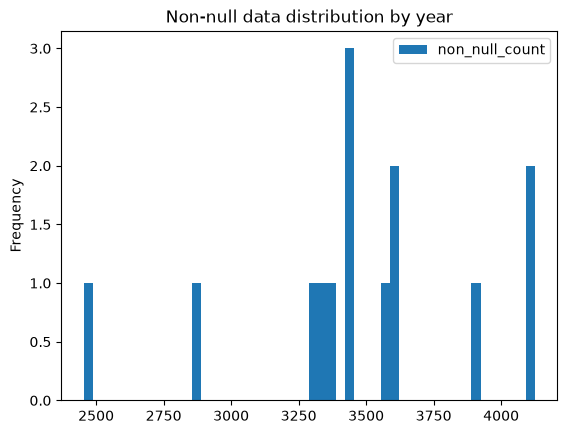

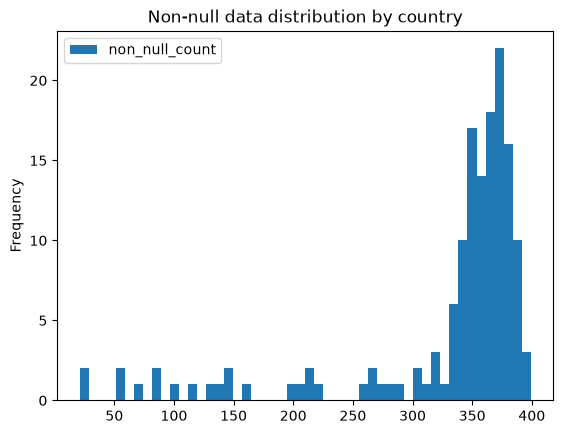

In [143]:
year_stats.plot.hist(bins=50, title="Non-null data distribution by year")
country_stats.plot.hist(bins=50, title="Non-null data distribution by country")

In [144]:
country_mode = country_stats["non_null_count"].mode()[0]
countries_w_mode = country_stats.loc[country_stats["non_null_count"] == country_mode,:].size
country_mean = country_stats["non_null_count"].mean()
country_outliers = country_stats.loc[country_stats["non_null_count"] < country_mean,:].size

print(f"Mode of non-null values per country: {country_mode}")
print(f"Mean of non-null values per country: {country_mean}")
print(f"Number of countries with same datapoints as the mode: {countries_w_mode}")
print(f"Number of countries with less data than the mean: {country_outliers}")


Mode of non-null values per country: 372
Mean of non-null values per country: 328.1418918918919
Number of countries with same datapoints as the mode: 8
Number of countries with less data than the mean: 32


What can we do from here and on? As more than the $75\%$ of all countries have more than 328 datapoints (the mean), that means that those 32 countries are dragging down the whole dataset. Here, the decision is to remove those countries:

In [145]:
outlier_country_names = country_stats.loc[country_stats["non_null_count"] < country_mean,:].index
no_country_outliers = valid_df.loc[~valid_df["Country name"].isin(outlier_country_names), :]

In [146]:
# Check only features
no_country_outliers.iloc[:, 3:20].describe()

,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Access to electricity (% of population),Agricultural land (% of land area),Alternative and nuclear energy (% of total energy use),Expense (% of GDP),Food production index (2014-2016 = 100),Forest area (% of land area),Fossil fuel energy consumption (% of total),GDP growth (annual %),GDP per capita growth (annual %),"Government expenditure on education, total (% of GDP)"
count,811.000000,811.000000,809.000000,811.000000,804.000000,805.000000,811.000000,1389.000000,1389.000000,1330.000000,1127.000000,1273.000000,1389.000000,406.000000,1619.000000,1614.000000,1200.000000
mean,1.300798,1.116561,0.568023,0.632741,0.149813,0.150600,1.764963,85.117927,41.938148,11.871917,26.590442,102.891665,31.383438,62.604196,3.136554,1.947118,4.267929
std,0.448470,0.349443,0.220447,0.198609,0.082239,0.123801,0.651481,26.012487,18.886916,15.201130,10.965907,13.019512,19.385367,27.122739,3.916843,3.819035,1.576066
min,0.108330,0.058000,0.017000,0.083944,0.003000,0.000830,-0.222000,4.100000,0.919220,0.010000,3.695458,62.400000,0.287611,-61.378855,-28.758584,-22.745681,0.319069
25%,0.982509,0.877500,0.409000,0.500000,0.092000,0.063000,1.353000,85.200000,29.759704,1.912500,17.112814,96.530000,14.458775,45.324703,1.501291,0.421408,3.175590
50%,1.333000,1.151000,0.568000,0.621000,0.138688,0.114826,1.809000,99.800000,42.849672,6.470000,25.944683,101.320000,31.860334,70.116690,3.339203,2.121960,4.191885
75%,1.668500,1.399839,0.727000,0.750000,0.197000,0.193000,2.203559,100.000000,53.875439,15.935000,34.855835,107.820000,44.871164,84.293646,5.261190,3.977903,5.277047
max,2.209000,1.840000,1.137814,1.147000,0.569814,0.587000,3.482000,100.000000,82.996229,100.000000,65.560022,183.450000,81.912168,99.887114,24.623986,23.452027,10.826554


In [147]:
no_country_outliers.iloc[:, 20:-1].describe()

,"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)","Literacy rate, adult total (% of people ages 15 and above)",Net migration,"PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)",Population growth (annual %),Population in urban agglomerations of more than 1 million (% of total population),Population living in areas where elevation is below 5 meters (% of total population),Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
count,1602.000000,1505.000000,416.000000,1.614000e+03,682.000000,1621.000000,1356.000000,89.000000,543.000000,746.000000,1274.000000,1087.000000,1120.000000,1607.000000,794.000000,1377.000000,1615.000000,1621.000000
mean,6.020853,73.158395,84.674309,4.467398e+03,90.147941,1.162169,25.048480,5.151249,25.481832,6.783244,1.440738,91.207666,37.571072,37.893083,0.990334,15.283588,6.939892,62.434186
std,19.483709,7.760625,17.751133,2.986096e+05,24.798888,1.327418,16.398944,7.453999,24.357144,13.904898,3.461624,14.451995,29.214670,20.262933,0.058379,10.933065,5.297931,20.477790
min,-4.763860,50.426000,22.309999,-5.699445e+06,0.258944,-8.423008,3.502841,0.013799,0.011010,0.100000,0.100000,33.537209,0.002155,4.061410,0.678300,0.500000,0.119000,15.552315
25%,1.597237,67.807000,78.017498,-2.475975e+04,97.918248,0.299667,13.739023,1.441168,1.482545,0.400000,0.100000,88.177069,12.753898,21.881062,0.980115,5.500000,3.573500,50.984741
50%,3.309137,74.576000,93.090000,-2.993000e+03,100.000000,1.129111,19.984876,2.611095,16.477140,1.200000,0.300000,96.824623,30.395412,35.679255,1.000435,14.000000,5.244000,64.524401
75%,6.240281,79.978049,96.302500,2.737475e+04,100.000000,1.966369,31.864083,6.004662,47.283200,5.550000,0.900000,99.482067,61.292848,49.093069,1.017518,22.100000,8.530500,78.648806
max,557.201817,84.560000,100.000000,1.889129e+06,100.000000,9.992305,100.000000,53.688095,92.496970,81.600000,22.800000,128.295324,99.997377,84.447685,1.175880,59.700000,34.007000,100.000000


In [148]:
# Check year and happiness score features
no_country_outliers.iloc[:, :3].describe()

,Year,Life evaluation (3-year average)
count,1621.000000,1621.000000
mean,2018.358421,5.603214
std,4.255915,1.111581
min,2011.000000,2.392000
25%,2015.000000,4.700000
50%,2019.000000,5.674100
75%,2022.000000,6.455000
max,2025.000000,7.856000


We have a much better dataset now, as we can observe that no feature holds a minimum of $0$, which has been deemed as `NaN` data (given the nature of the features).
Let's save our progress:

In [149]:
save_csv("no_country_outliers", no_country_outliers)

Now, we shall recall that there where some countries with missing data, and we haven't dealt with that problem yet. As most outliers are now gone, we can compute the mean for each country, as it makes sense that indicators move around the mean throughout the years. Let's replace missing data, per country, by the feature's mean:

# Data Exploration and Visualization